In [2]:
import sys
sys.path.append('../../')

In [3]:
%load_ext autoreload
%autoreload 2

In [23]:
import pandas as pd
import torch
import os

from src.core.mot.data import MOT17Dataset, collate_fn
from src.config.paths import DATA_PATH

# Setup

## Model Loading

In [5]:
model:torch.nn.Module

attempts = 1
MAX_ATTEMPTS = 5
while attempts <= MAX_ATTEMPTS:
    print(f'[{attempts}/{MAX_ATTEMPTS}] Loading Model...')
    attempts += 1

    try:
        model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
        print('[Success] Loaded Pretrained Model')
        break
    except ImportError as e:
        print('[Error]', e)

[1/5] Loading Model...


Using cache found in C:\Users\abi/.cache\torch\hub\pytorch_vision_v0.10.0
c:\Users\abi\miniconda3\envs\btyi\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\abi\miniconda3\envs\btyi\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[Success] Loaded Pretrained Model


In [6]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [7]:
model.to('cuda')
model.eval()
model.fc = torch.nn.Identity()

## Validation

In [8]:
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        # these values are ImageNet's means and sds
])

img = [
    preprocess(PIL.Image.open(DATA_PATH / 'MOT17' / 'train' / 'MOT17-05-FRCNN' / 'img1' / f'{i:06d}.jpg'))
    for i in range(1,256)
]
X = torch.stack(img).to('cuda')
y = model(X)

X.shape, y.shape

(torch.Size([255, 3, 224, 224]), torch.Size([255, 512]))

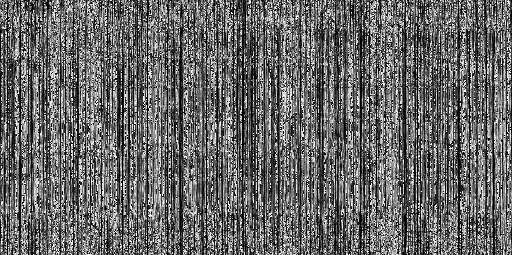

In [9]:
torchvision.transforms.ToPILImage(
)(y.view(-1,512).to('cpu').detach())

In [10]:
del X
del y
del img

# Dataset

## Structuring the Data

In [11]:
def construct_dicts(path):
    """ 
        Output Structure:
        ```    
        {
            challenge_name: {
                frame_id: {                
                    'gt': {
                        tracklet_id: [
                            {
                                'bb_left',
                                'bb_top',
                                'bb_width',
                                'bb_height',
                                'conf',
                                'visibility',
                            }
                        ],
                        tracklet_id: [...],
                        ...
                    }
                    'dets': [
                        {
                            'bb_left',
                            'bb_top',
                            'bb_width',
                            'bb_height',
                            'conf'
                        }
                    ]
                },
                frame_id: {...},
                ...
            },
            challenge_name: {...},
            ...
        }
        ```
    """

    result = {}

    mot17_cols = ['frame', 'id', 'bb_left', 'bb_top', 'bb_width', 'bb_height', 'conf', 'class', 'visibility'] 
    frcnn_challenges = [i for i in os.listdir(str(path)) if 'FRCNN' in i]

    for challenge in frcnn_challenges:
        gt = pd.read_csv(
            str(path / challenge / 'gt' / 'gt.txt'),
            names=mot17_cols,
            header=None
        )
        dets = pd.read_csv(
            str(path / challenge / 'det' / 'det.txt'),
            names=mot17_cols,
            header=None
        )

        gt = gt.drop(['class'], axis=1)
        print(challenge, len(gt['conf'].unique()), len(dets['conf'].unique()))

        result[challenge] = {}
        frames = len(os.listdir(str(path / challenge / 'img1')))
        for f in range(1, frames + 1):
            result[challenge][f] = {
                'gt': [],
                'dets': []
            }

            gt_f = gt[gt['frame'] == f]
            det_f = dets[dets['frame'] == f]

            gt_f = gt_f.drop(['frame'], axis=1)
            result[challenge][f]['gt'] = gt_f.to_dict(orient='records')

            det_f = det_f.drop(['frame', 'class', 'visibility'], axis=1)
            result[challenge][f]['dets'] = det_f.to_dict(orient='records')

    return result

In [12]:
path = DATA_PATH / 'MOT17'
data = construct_dicts(path / 'train')

MOT17-02-FRCNN 2 669
MOT17-04-FRCNN 2 610
MOT17-05-FRCNN 2 398
MOT17-09-FRCNN 2 212
MOT17-10-FRCNN 2 789
MOT17-11-FRCNN 2 471
MOT17-13-FRCNN 2 840


In [13]:
data['MOT17-02-FRCNN']

{1: {'gt': [{'id': 1,
    'bb_left': 912,
    'bb_top': 484,
    'bb_width': 97,
    'bb_height': 109,
    'conf': 0,
    'visibility': 1.0},
   {'id': 2,
    'bb_left': 1338,
    'bb_top': 418,
    'bb_width': 167,
    'bb_height': 379,
    'conf': 1,
    'visibility': 1.0},
   {'id': 3,
    'bb_left': 586,
    'bb_top': 447,
    'bb_width': 85,
    'bb_height': 263,
    'conf': 1,
    'visibility': 1.0},
   {'id': 4,
    'bb_left': 1585,
    'bb_top': -1,
    'bb_width': 336,
    'bb_height': 578,
    'conf': 0,
    'visibility': 0.98153},
   {'id': 5,
    'bb_left': 1163,
    'bb_top': 441,
    'bb_width': 33,
    'bb_height': 89,
    'conf': 0,
    'visibility': 1.0},
   {'id': 6,
    'bb_left': 1308,
    'bb_top': 431,
    'bb_width': 34,
    'bb_height': 118,
    'conf': 0,
    'visibility': 0.85714},
   {'id': 8,
    'bb_left': 1416,
    'bb_top': 431,
    'bb_width': 184,
    'bb_height': 336,
    'conf': 1,
    'visibility': 0.51351},
   {'id': 9,
    'bb_left': 1056,
    'bb_

## The Class

In [20]:
ds = MOT17Dataset(data, DATA_PATH / 'MOT17' / 'train', False)
ds[-1][0].shape

torch.Size([3, 1080, 1920])

In [ ]:
dl = torch.utils.data.DataLoader(ds, 4, collate_fn=collate_fn)